## Name:     Hadi Al Abu Allairat
## ID:       2230005761
## Section:  8MA1

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Task 1: Thresholding
## Step 1: Apply thresholding with a fixed threshold on an image:
In image processing, thresholding is a common technique used to separate objects or regions in an image based on their pixel intensities. It involves converting a grayscale or color image into a binary image, where pixels are classified as either "foreground" or "background" based on a specified threshold value.  

The threshold value acts as a dividing point, determining which pixels are considered part of the foreground (above the threshold) and which are part of the background (below the threshold). The process of thresholding essentially simplifies the image by reducing the pixel values to two categories, simplifying subsequent analysis or feature extraction. The result of thresholding is a binary image where foreground objects are represented by white pixels and background areas are represented by black pixels.  

Thresholding can be used for various image processing tasks, such as image segmentation, object detection, and feature extraction. Different thresholding techniques and algorithms exist to handle specific scenarios, such as adaptive thresholding, where the threshold value varies across different regions of the image.  

It's important to note that choosing an appropriate threshold value can be challenging, as it depends on factors like image quality, lighting conditions, and the characteristics of the objects or regions of interest. Experimentation and adjusting the threshold value may be necessary to achieve desired results.


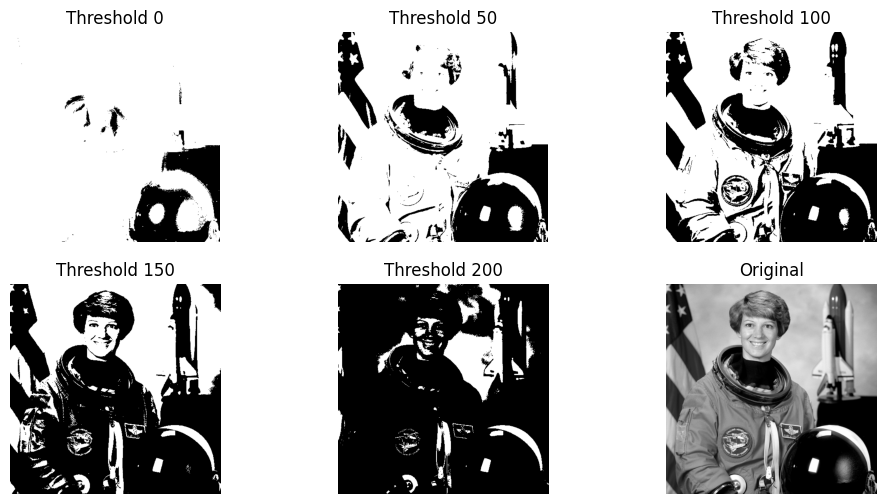

In [3]:
import cv2
import matplotlib.pyplot as plt
from skimage import data

# Load image and convert to uint8
img = data.astronaut()
img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Threshold values
threshold_values = [0, 50, 100, 150, 200]

plt.figure(figsize=(12,6))

for i, t in enumerate(threshold_values):
    ret, thresh = cv2.threshold(img, t, 255, cv2.THRESH_BINARY)

    plt.subplot(2,3,i+1)
    plt.imshow(thresh, cmap='gray')
    plt.title(f"Threshold {t}")
    plt.axis('off')

plt.subplot(2,3,6)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.show()

# Task 2: Histogram Processing  

## Step 1: Load necessary libraries

In [4]:
from skimage import data, img_as_float
from skimage import exposure

## Step 2: Load moon image


In [5]:
img = data.moon()

## Step 3: 
Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles

In [6]:
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

## Step 4:
Display the image with its histogram of (step#2)  and (step#3)

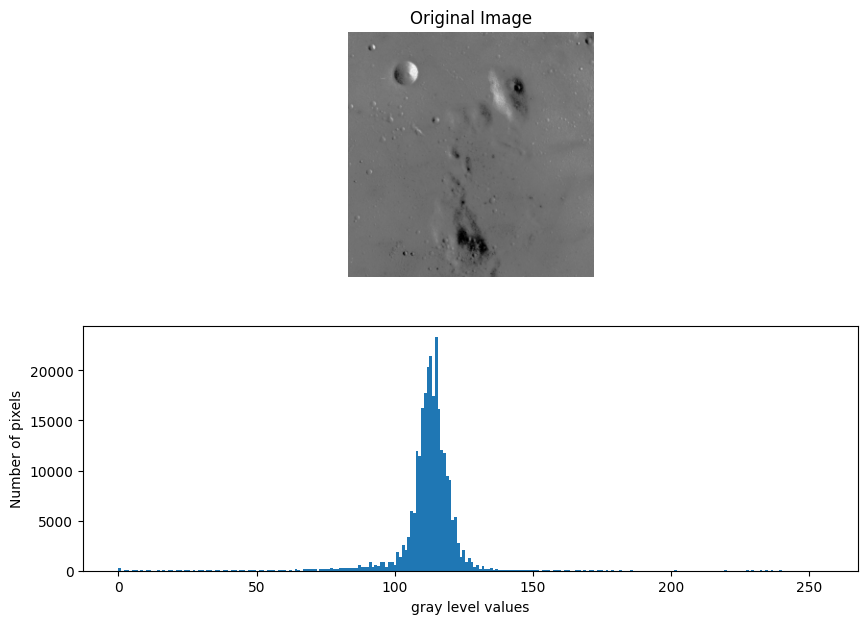

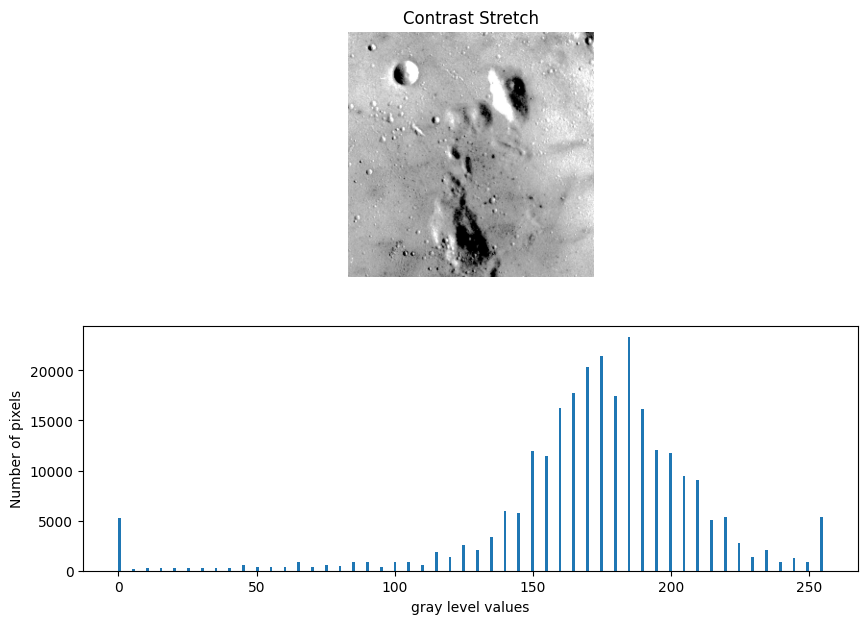

In [7]:
def image_intensity(image1, label):
    fig = plt.figure(figsize=(10, 7))
    
    fig.add_subplot(2, 1, 1) 
    plt.imshow(image1, cmap = 'gray') 
    plt.axis('off') 
    plt.title(label)
    
    fig.add_subplot(2, 1, 2) 
    plt.hist(image1.flat, bins = 256, range=(0, 255)) 
    plt.xlabel('gray level values') 
    plt.ylabel('Number of pixels') 
    
    plt.show() 
    

image_intensity(img, "Original Image")
image_intensity(img_rescale, "Contrast Stretch")

# Task 1
Using the same ‘moon image’ Rescale intensity values to include all the intensities that fall within the 3nd and 80th percentiles, and plot the histogram

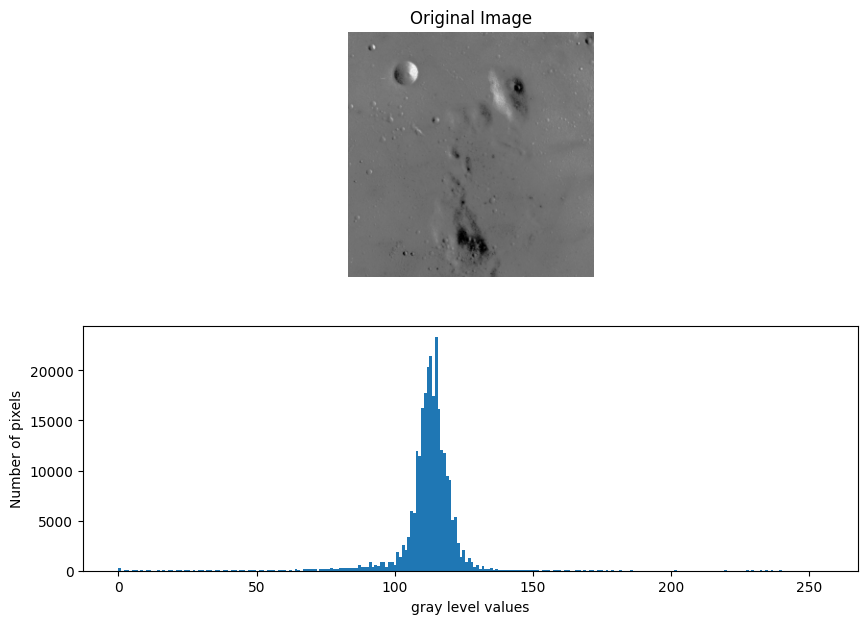

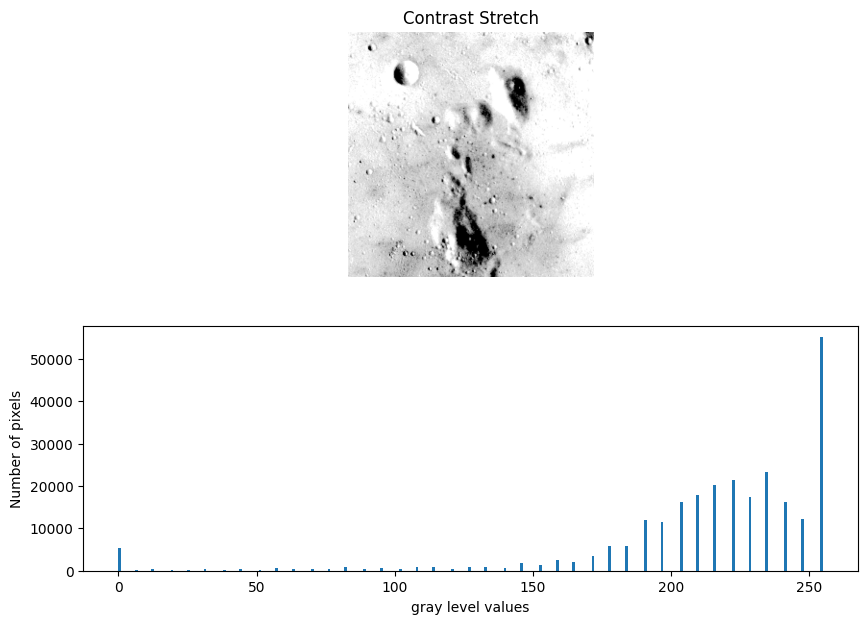

In [8]:
p2, p80 = np.percentile(img, (2, 80))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p80))

image_intensity(img, "Original Image")
image_intensity(img_rescale, "Contrast Stretch")

# Task 2:   
Using the same ‘moon image’ and the <a href="https://scikit-image.org/docs/stable/api/skimage.exposure.html#skimage.exposure.equalize_hist">exposure.equalize_hist()</a> function, display the image and the histogram of the image after flattening the histogram.

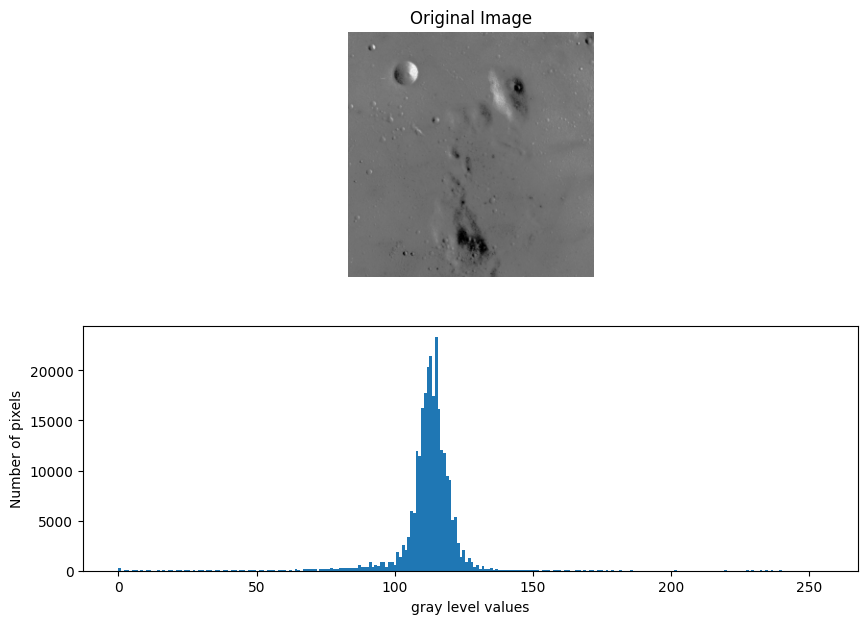

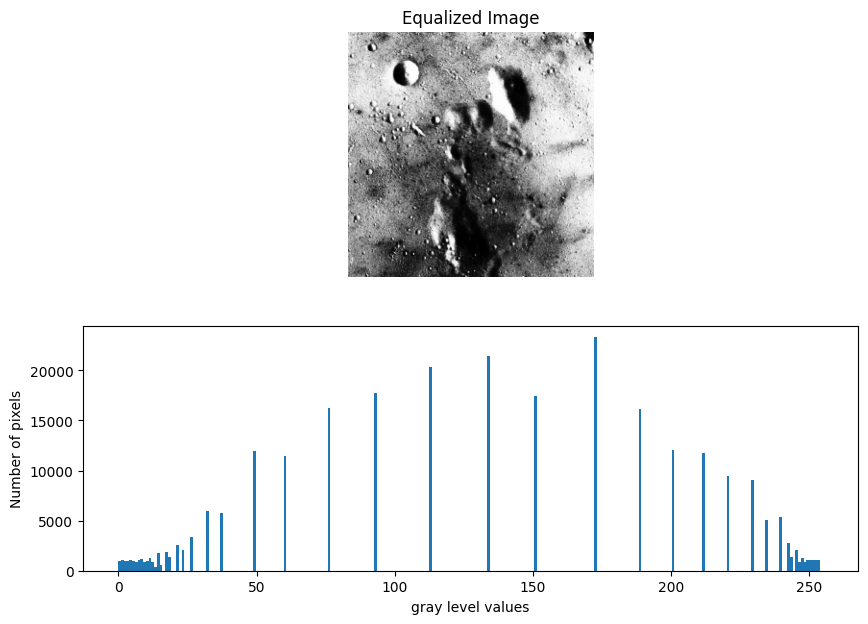

In [9]:
new_image = exposure.equalize_hist(img)
new_image = np.floor(new_image*255)
image_intensity(img, "Original Image")
image_intensity(new_image, "Equalized Image")

# Task 3
Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching

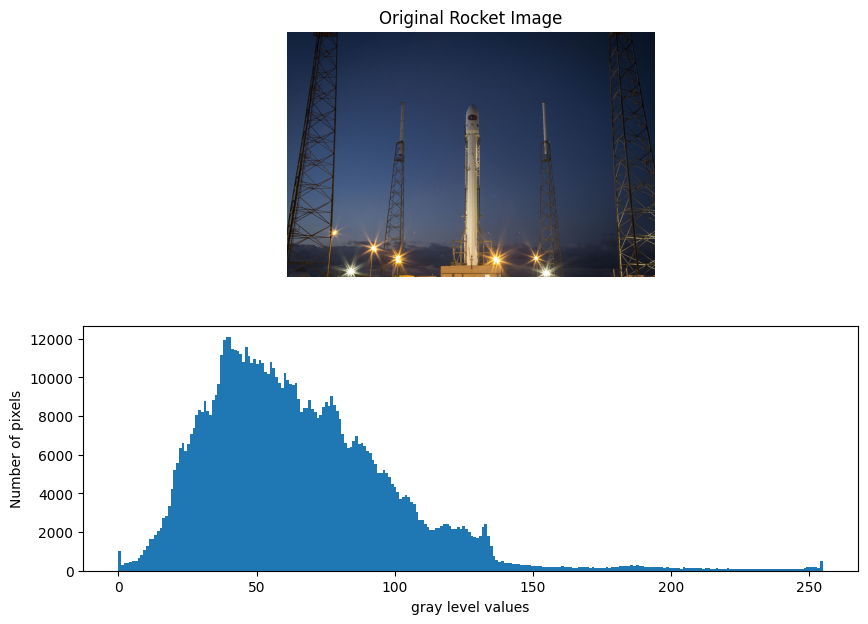

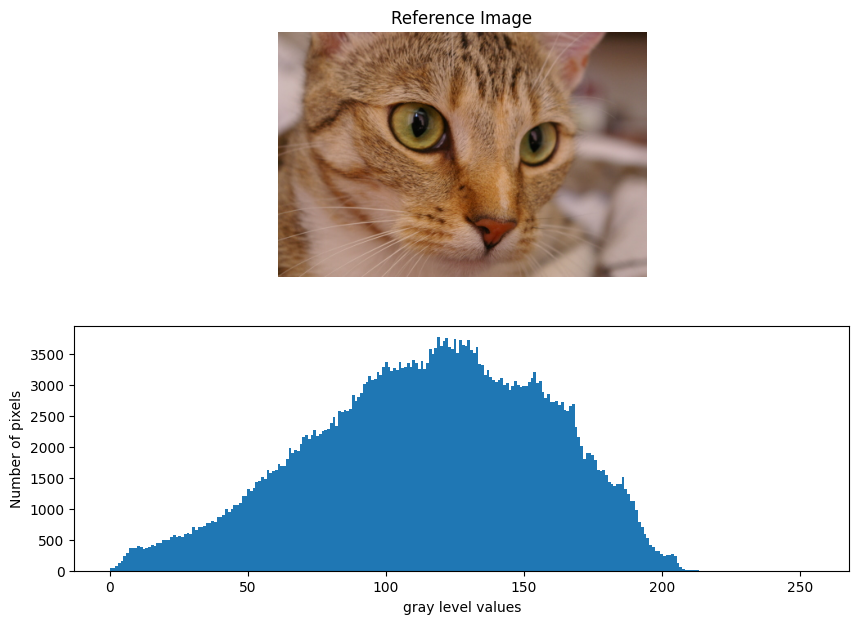

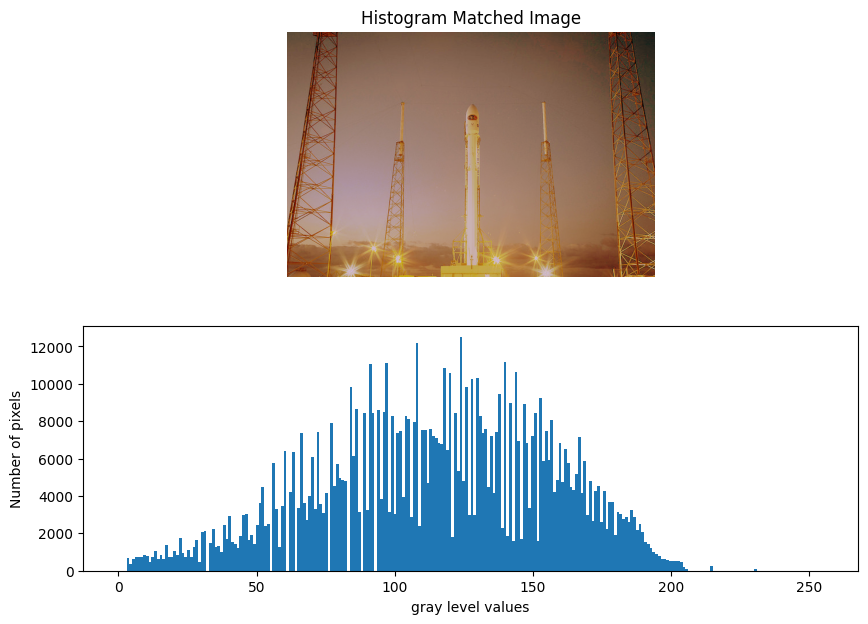

In [10]:
rocket_img = data.rocket()
chelsea_img = data.chelsea()
output_img = exposure.match_histograms(rocket_img, chelsea_img, channel_axis=-1)

image_intensity(rocket_img, "Original Rocket Image")
image_intensity(chelsea_img, "Reference Image")
image_intensity(output_img, "Histogram Matched Image")